# Olist E-Commerce Sales Analysis

Tools: Python | Pandas | NumPy | Matplotlib | Power BI

Skills Demonstrated:
• Data Cleaning
• Exploratory Data Analysis
• Data Visualization
• Business Analytics
• Power BI Dashboard Development

# Project overview

This project analyzes sales performance and customer behavior using the Olist Brazilian e-commerce dataset. The objective was to clean the data, perform exploratory analysis, and build interactive Power BI dashboards that highlight key business trends and customer insights.



# Dataset Description

The project is based on the Olist Brazilian E-Commerce dataset, a public dataset containing information about orders placed between 2016 and 2018. The original dataset includes customers, orders, products, sellers, payments, reviews, and geolocation data.

For this analysis, cleaned datasets were prepared to focus on sales performance, product categories, and customer spending behavior.

## Executive Summary

The analysis focuses on answering the following business questions:

- How did revenue and order volume evolve over time?
- Which product categories contribute most to revenue?
- Was business growth driven by higher order values or increasing order volume?
- How is revenue distributed across product categories and customers?
- What customer purchasing patterns can be identified?

The findings provide actionable insights into business growth, product performance, and customer behavior while demonstrating a complete analytics workflow from raw data preparation to interactive business intelligence reporting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Data Preparation

In [2]:
orders = pd.read_csv('/content/olist_orders_dataset.csv')
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
# Initial exploration of the dataset
orders.shape
orders.info()
orders.head()

orders.describe()
orders.describe(include='object')

orders.isnull().sum()
orders.duplicated().sum()

orders.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [4]:
# Initial Data Preparation

# Review order status distribution
orders['order_status'].value_counts()

# Convert date columns to datetime format
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

# Create delivery time feature (in days)
orders['delivery_time_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.days

# Review delivery time statistics
orders['delivery_time_days'].describe()

,delivery_time_days
count,96476.000000
mean,12.094086
std,9.551746
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


# Exploratory Data Analysis

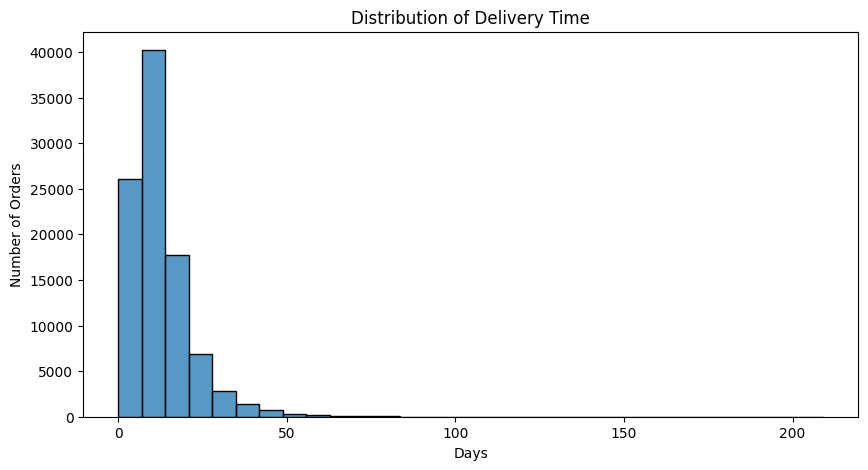

In [5]:
# Distribution of delivery time
plt.figure(figsize=(10,5))

sns.histplot(orders['delivery_time_days'], bins=30)

plt.title('Distribution of Delivery Time')
plt.xlabel('Days')
plt.ylabel('Number of Orders')

plt.show()

Delivery times are right-skewed, with most orders delivered within a relatively short period.

In [6]:
# Create a monthly purchase feature
orders['purchase_month'] = (
    orders['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

# Preview the new feature
orders['purchase_month'].head()

,purchase_month
0,2017-10
1,2018-07
2,2018-08
3,2017-11
4,2018-02


In [7]:
# Load the order items dataset
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')

# Merge orders with order items
sales = orders.merge(
    order_items,
    on='order_id',
    how='inner'
)

# Review the merged dataset
sales.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_time_days',
 'purchase_month',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value']

In [8]:
# Examine the distribution of order statuses
orders['order_status'].value_counts()

# Calculate the cancellation rate
cancellation_rate = (
    orders['order_status']
    .eq('canceled')
    .mean() * 100
)

print(f'Cancellation Rate: {cancellation_rate:.2f}%')

Cancellation Rate: 0.63%


Only 0.63% of orders were canceled, indicating relatively stable operational performance throughout the analyzed period.

In [9]:
# Calculate the number of unique orders per month
monthly_orders = (
    sales
    .groupby('purchase_month')['order_id']
    .nunique()
    .reset_index(name='num_orders')
)

monthly_orders.head()

,purchase_month,num_orders
0,2016-09,3
1,2016-10,308
2,2016-12,1
3,2017-01,789
4,2017-02,1733


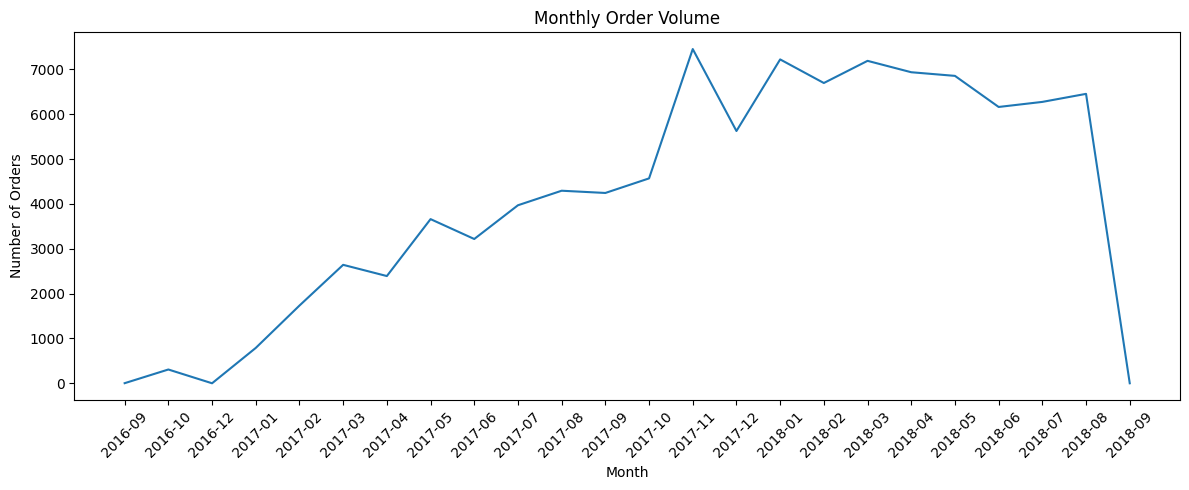

In [10]:
# Visualize monthly order volume over time

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_orders,
    x='purchase_month',
    y='num_orders'
)

plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Monthly order volume increased substantially throughout 2017 and early 2018, following a pattern similar to monthly revenue. This suggests that business growth was associated with increasing customer demand.

In [11]:
# Calculate monthly revenue
monthly_revenue = (
    sales
    .groupby('purchase_month')['price']
    .sum()
    .reset_index()
)

# Preview the aggregated data
monthly_revenue.head()

,purchase_month,price
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


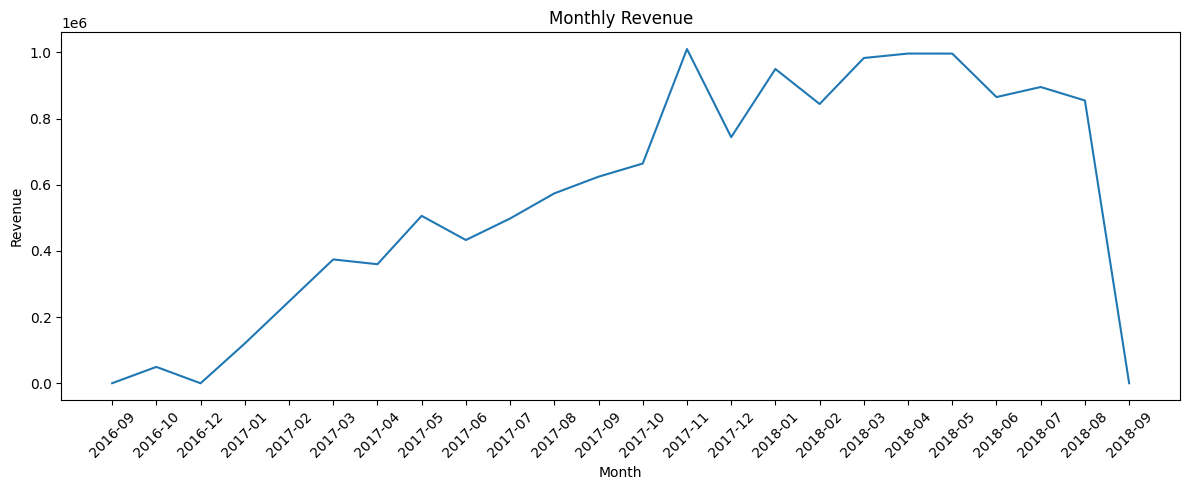

In [12]:
# Visualize monthly revenue over time
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_revenue,
    x='purchase_month',
    y='price'
)

plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Revenue showed an overall upward trend throughout 2017 and early 2018, despite normal month-to-month fluctuations.
The final month contained incomplete transaction data and was excluded from time-series analyses to avoid misleading trend interpretation.



In [13]:
# Validate time range of the dataset
print(sales['purchase_month'].min())
print(sales['purchase_month'].max())

# Identify top-performing months by revenue
monthly_revenue.sort_values(
    by='price',
    ascending=False
).head(10)

2016-09
2018-09


,purchase_month,price
13,2017-11,1010271.37
18,2018-04,996647.75
19,2018-05,996517.68
17,2018-03,983213.44
15,2018-01,950030.36
21,2018-07,895507.22
20,2018-06,865124.31
22,2018-08,854686.33
16,2018-02,844178.71
14,2017-12,743914.17


Revenue grew substantially throughout the observed period.

The platform experienced significant revenue growth between 2017 and 2018.

The earliest months contain unusually low revenue values. These months likely represent partial data coverage and should be interpreted with caution.

In [14]:
# Calculate month-over-month revenue growth
monthly_revenue['growth_pct'] = (
    monthly_revenue['price']
    .pct_change() * 100
)

# Review monthly revenue growth rates
monthly_revenue[['purchase_month', 'price', 'growth_pct']]

,purchase_month,price,growth_pct
0,2016-09,267.36,NaN
1,2016-10,49507.66,1.841723e+04
2,2016-12,10.90,-9.997798e+01
3,2017-01,120312.87,1.103688e+06
4,2017-02,247303.02,1.055499e+02
5,2017-03,374344.30,5.137069e+01
6,2017-04,359927.23,-3.851286e+00
7,2017-05,506071.14,4.060374e+01
8,2017-06,433038.60,-1.443128e+01
9,2017-07,498031.48,1.500857e+01


In [15]:
# Exclude partial months from the growth analysis
monthly_revenue_clean = (
    monthly_revenue[
        (monthly_revenue['purchase_month'] >= '2017-01') &
        (monthly_revenue['purchase_month'] < '2018-09')
    ].copy()
)

# Recalculate month-over-month revenue growth
monthly_revenue_clean['growth_pct'] = (
    monthly_revenue_clean['price']
    .pct_change() * 100
)

The first and last months contain partial data, resulting in unusually large month-over-month changes. Growth rates should therefore be interpreted with caution.

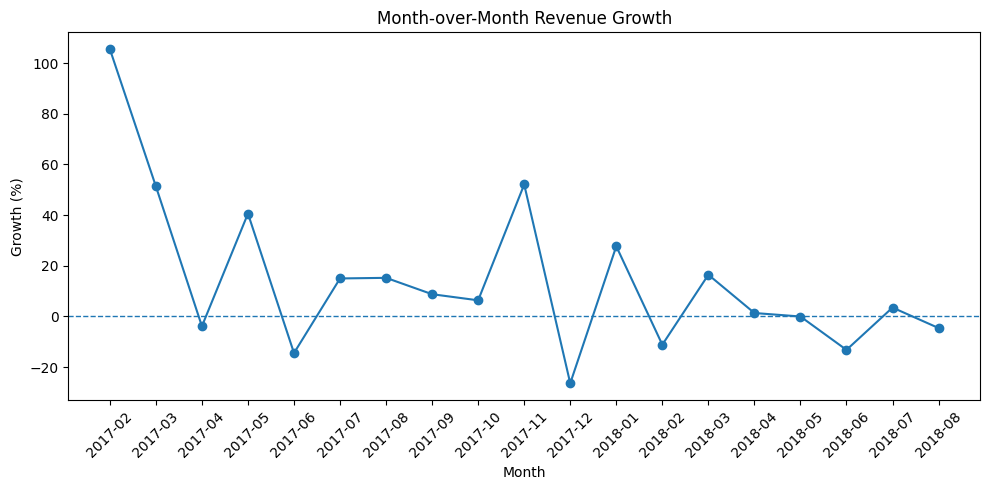

In [16]:
# Visualize month-over-month revenue growth
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue_clean['purchase_month'],
    monthly_revenue_clean['growth_pct'],
    marker='o'
)

plt.axhline(0, linestyle='--', linewidth=1)

plt.title('Month-over-Month Revenue Growth')
plt.xlabel('Month')
plt.ylabel('Growth (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

After excluding incomplete months, month-over-month revenue growth shows regular fluctuations rather than a consistent upward trend. Several months experienced strong growth, while occasional declines indicate normal variability in sales performance.

In [17]:
# Investigate whether revenue growth was driven by higher order values or more orders
# Calculate total revenue for each order
order_revenue = (
    sales
    .groupby('order_id')['price']
    .sum()
)

# Prepare monthly order revenue for AOV trend analysis
order_monthly_revenue = (
    sales[['order_id', 'purchase_month']]
    .drop_duplicates()
    .merge(order_revenue, on='order_id')
)

order_monthly_revenue.head()


,order_id,purchase_month,price
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02,19.90


In [18]:
# Calculate Average Order Value (AOV)
order_revenue = (
    sales
    .groupby('order_id')['price']
    .sum()
)

aov = order_revenue.mean()

print(f'Average Order Value: {aov:.2f}')

Average Order Value: 137.75


In [19]:
# Calculate the average order value for each month
monthly_aov = (
    order_monthly_revenue
    .groupby('purchase_month')['price']
    .mean()
    .reset_index()
)

# Review the resulting monthly AOV values
monthly_aov.head()

monthly_aov['price'].describe()

,price
count,24.000000
mean,132.708731
std,29.144418
min,10.900000
25%,132.420056
50%,139.356531
75%,145.101764
max,160.739156


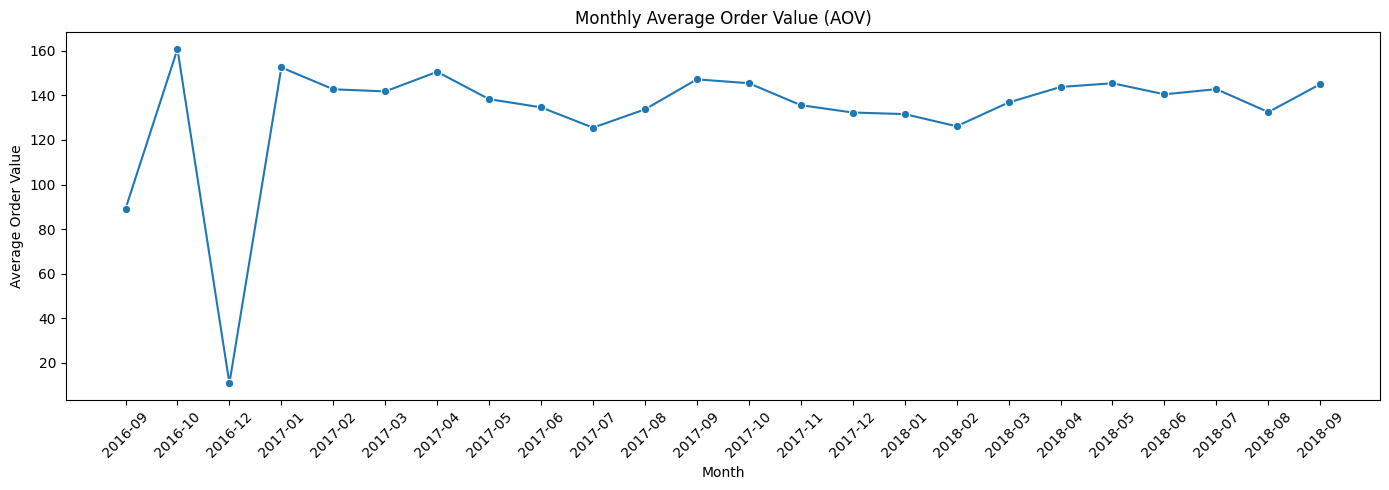

In [20]:
# Visualize monthly Average Order Value (AOV) over time
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=monthly_aov,
    x='purchase_month',
    y='price',
    marker='o'
)

plt.title('Monthly Average Order Value (AOV)')
plt.xlabel('Month')
plt.ylabel('Average Order Value')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

After the initial partial months, Average Order Value remained relatively stable throughout the analyzed period, fluctuating within a relatively narrow range. This suggests that revenue growth was primarily driven by increasing order volume rather than higher spending per order.

## Revenue & Orders Insights:

Strong business growth:
Order volume and revenue increased substantially throughout 2017 and early 2018.

Revenue growth was driven by order volume:
Average Order Value remained relatively stable throughout the observed period, suggesting that revenue growth was primarily driven by an increase in the number of orders rather than higher spending per order.

Incomplete data at the dataset boundaries:
The unusually low values at the beginning and end of the timeline likely reflect partial monthly data rather than actual business performance.

In [21]:
# Investigate whether customers purchased more items per order
items_per_order = (
    sales
    .groupby('order_id')['order_item_id']
    .count()
)

items_per_order.describe()

,order_item_id
count,98666.000000
mean,1.141731
std,0.538452
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,21.000000


In [22]:
# Review the distribution of items per order
items_per_order.value_counts().sort_index()

,count
order_item_id,
1,88863
2,7516
3,1322
4,505
5,204
6,198
7,22
8,8
9,3


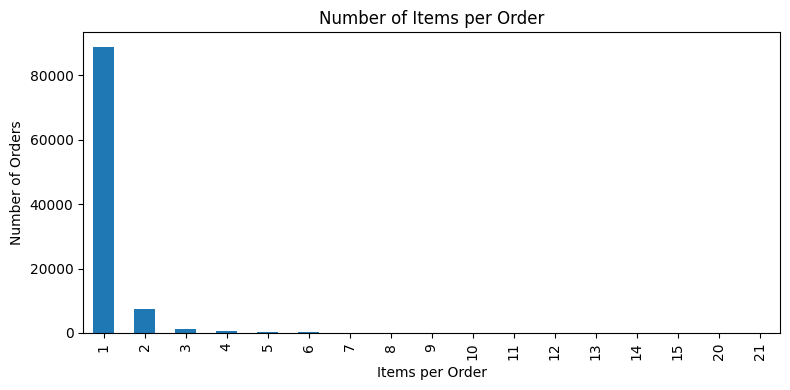

In [23]:
# Visualize the distribution of items per order
plt.figure(figsize=(8, 4))

items_per_order.value_counts().sort_index().plot(kind='bar')

plt.title('Number of Items per Order')
plt.xlabel('Items per Order')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

# Product Analysis

In [24]:
# Load product and category datasets
products = pd.read_csv('/content/olist_products_dataset.csv')

category_translation = pd.read_csv('/content/product_category_name_translation.csv')

category_translation.head()

products.columns.tolist()
category_translation.columns.tolist()

['product_category_name', 'product_category_name_english']

In [25]:
# Merge sales with product information
sales_products = sales.merge(
    products,
    on='product_id',
    how='left'
)

# Add English product category names
sales_products = sales_products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

# Verify that product categories were translated successfully
sales_products[
    [
        'product_category_name',
        'product_category_name_english'
    ]
].head()

,product_category_name,product_category_name_english
0,utilidades_domesticas,housewares
1,perfumaria,perfumery
2,automotivo,auto
3,pet_shop,pet_shop
4,papelaria,stationery


In [26]:
# Calculate total revenue by product category
category_revenue = (
    sales_products
    .groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Review the top revenue-generating categories
category_revenue.head(10)

,product_category_name_english,price
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


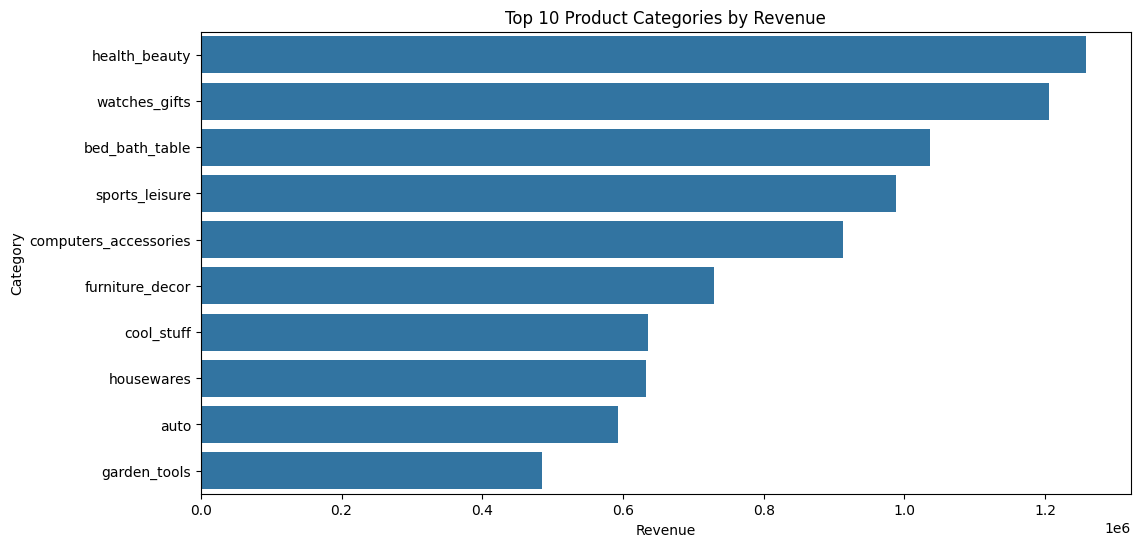

In [27]:
# Visualize the top 10 product categories by revenue
top10 = category_revenue.head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top10,
    y='product_category_name_english',
    x='price'
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Category')

plt.show()

## Product Categories Insights:

No single dominant category:
Health & Beauty is the top-performing category, but the revenue gap between the leading categories is relatively small, indicating a balanced competitive landscape rather than dominance by a single segment.

Strong performance across multiple categories:
Categories such as Watches & Gifts, Bed, Bath & Table, Sports & Leisure, and Computers Accessories all contribute significantly to total revenue, suggesting a diversified and healthy product portfolio.

Revenue concentration in mid-tier cluster:
Most of the top 10 categories generate comparable revenue levels, indicating that business performance is driven by multiple strong categories rather than reliance on one or two flagship segments.

In [28]:
 # Most Ordered Product Categories
 # Compare order volume with revenue across product categories

category_orders = (
    sales_products
    .groupby('product_category_name_english')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name='num_orders')
)

category_orders.head(10)

,product_category_name_english,num_orders
0,bed_bath_table,9417
1,health_beauty,8836
2,sports_leisure,7720
3,computers_accessories,6689
4,furniture_decor,6449
5,housewares,5884
6,watches_gifts,5624
7,telephony,4199
8,auto,3897
9,toys,3886


In [29]:
# Combine revenue and order metrics by product category
category_compare = category_revenue.merge(
    category_orders,
    on='product_category_name_english'
)

category_compare.head()

,product_category_name_english,price,num_orders
0,health_beauty,1258681.34,8836
1,watches_gifts,1205005.68,5624
2,bed_bath_table,1036988.68,9417
3,sports_leisure,988048.97,7720
4,computers_accessories,911954.32,6689


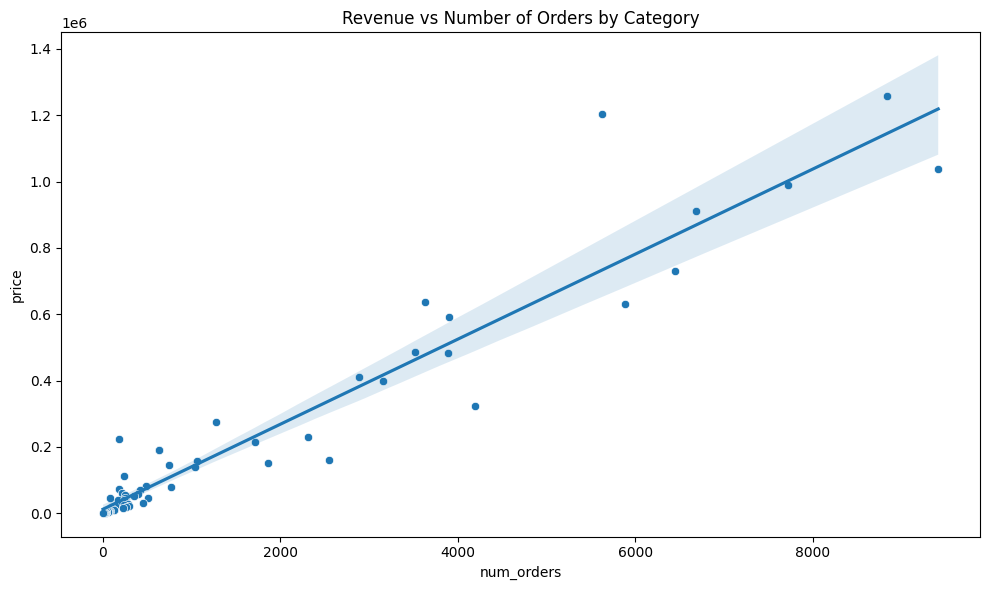

In [30]:
# Visualize the relationship between order volume and revenue
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=category_compare,
    x='num_orders',
    y='price'
)

plt.title('Revenue vs Number of Orders by Category')
plt.xlabel('Number of Orders')
plt.ylabel('Revenue')

sns.regplot(
    data=category_compare,
    x='num_orders',
    y='price',
    scatter=False
)

plt.tight_layout()
plt.show()

Product categories with a higher number of orders generally generated higher total revenue, although the relationship was not identical across all categories.

In [31]:
# Calculate average revenue per order for each product category
category_compare['revenue_per_order'] = (
    category_compare['price'] / category_compare['num_orders']
)

category_compare.sort_values(
    'revenue_per_order',
    ascending=False
).head(10)

,product_category_name_english,price,num_orders,revenue_per_order
16,computers,222963.13,181,1231.840497
34,small_appliances_home_oven_and_coffee,47445.71,75,632.609467
25,home_appliances_2,113317.74,234,484.263846
28,agro_industry_and_commerce,72530.47,182,398.519066
18,musical_instruments,191498.88,628,304.934522
19,small_appliances,190648.58,630,302.616794
30,fixed_telephony,59583.00,217,274.576037
38,construction_tools_safety,40544.52,167,242.781557
32,air_conditioning,55024.96,253,217.489960
14,office_furniture,273960.70,1273,215.208720


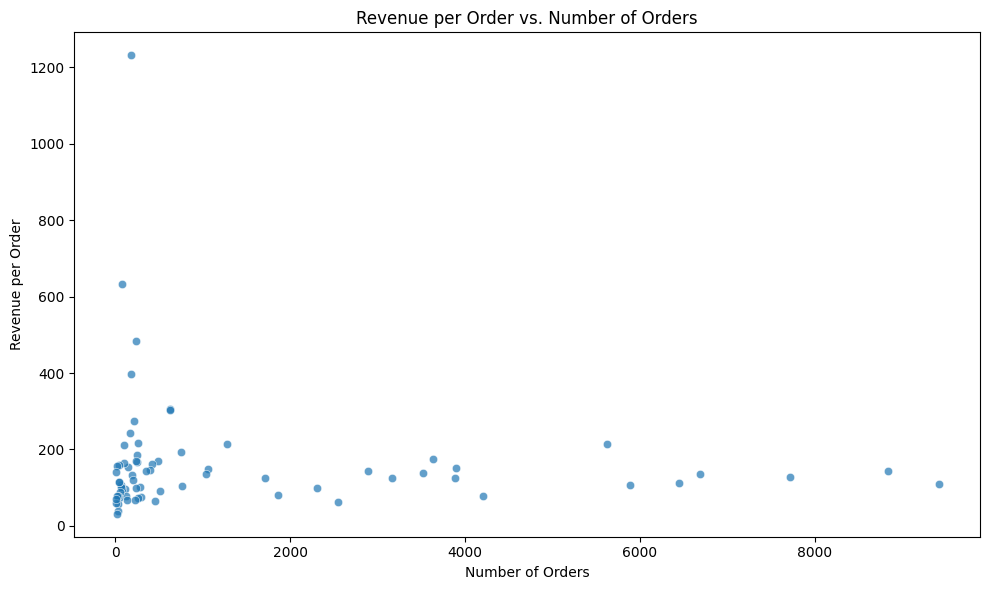

In [32]:
# Visualize category efficiency
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=category_compare,
    x='num_orders',
    y='revenue_per_order',
    alpha=0.7
)

plt.title('Revenue per Order vs. Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Revenue per Order')

plt.tight_layout()
plt.show()

Product categories vary in their average revenue per order, suggesting that some categories rely on higher-value purchases while others generate revenue through higher sales volume.

In [33]:
# Calculate each category's contribution to total revenue
category_compare['revenue_share'] = (
    category_compare['price'] /
    category_compare['price'].sum() * 100
)

# Display the top categories by revenue share
category_compare.sort_values(
    'revenue_share',
    ascending=False
).head(10)


,product_category_name_english,price,num_orders,revenue_per_order,revenue_share
0,health_beauty,1258681.34,8836,142.449224,9.388524
1,watches_gifts,1205005.68,5624,214.261323,8.988157
2,bed_bath_table,1036988.68,9417,110.118794,7.734915
3,sports_leisure,988048.97,7720,127.985618,7.369873
4,computers_accessories,911954.32,6689,136.336421,6.802282
5,furniture_decor,729762.49,6449,113.159015,5.443310
6,cool_stuff,635290.85,3632,174.914882,4.738645
7,housewares,632248.66,5884,107.452186,4.715953
8,auto,592720.11,3897,152.096513,4.421109
9,garden_tools,485256.46,3518,137.935321,3.619536


## Category Analysis Insights:

Revenue concentration:
A relatively small number of product categories generated a large share of total revenue, indicating moderate revenue concentration.

Different revenue models:
Categories generated revenue through different patterns: some relied on high order volume, while others achieved higher revenue per order.

Diversified portfolio:
No single category dominated total revenue, suggesting a diversified product portfolio with reduced dependence on any individual category.

Business implications:
The results suggest that marketing and inventory strategies should be tailored to each category's revenue model rather than applied uniformly.

# Customer Analysis

In [34]:
# Load customer dataset
customers = pd.read_csv('/content/olist_customers_dataset.csv')

customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [35]:
# Add unique customer identifier
sales = sales.merge(
    customers[
        ['customer_id', 'customer_unique_id']
    ],
    on='customer_id',
    how='left'
)

# Verify that the unique customer identifier was added successfully
sales[
    ['customer_id', 'customer_unique_id']
].head()

,customer_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff
1,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231
2,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8
3,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977
4,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6


In [36]:
# Calculate the number of orders placed by each customer
orders_per_customer = (
    sales.groupby('customer_unique_id')['order_id']
    .nunique()
)

# Summarize the distribution of customer purchase frequency
orders_per_customer.describe()

,order_id
count,95420.000000
mean,1.034018
std,0.211234
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,16.000000


In [37]:
# Classify customers based on purchase frequency
customer_type = orders_per_customer.apply(
    lambda x: 'Repeat' if x > 1 else 'One-time'
).value_counts()

customer_type

,count
order_id,
One-time,92507
Repeat,2913


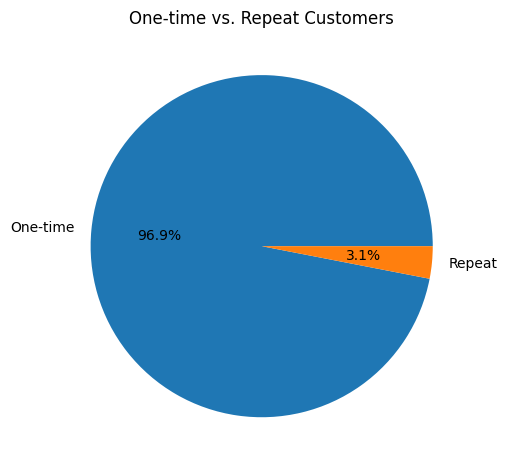

In [38]:
# Visualize customer types
customer_type.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('One-time vs. Repeat Customers')
plt.ylabel('')

plt.tight_layout()
plt.show()

Most customers placed only a single order during the observed period, while only about 3% returned for additional purchases. This suggests that repeat purchasing was relatively uncommon in the available dataset.

In [39]:
# Calculate total revenue generated by each customer
customer_revenue = (
    sales.groupby('customer_unique_id')['price']
    .sum()
    .sort_values(ascending=False)
    .reset_index(name='total_spent')
)

customer_revenue.head(10)

# Summarize customer spending distribution
customer_revenue['total_spent'].describe()

,total_spent
count,95420.000000
mean,142.440198
std,217.656355
min,0.850000
25%,47.900000
50%,89.900000
75%,155.000000
max,13440.000000


In [40]:
# Sort customers by total spending
customer_revenue_sorted = customer_revenue.sort_values('total_spent', ascending=False)

# Calculate cumulative revenue contribution
customer_revenue_sorted['cum_revenue'] = customer_revenue_sorted['total_spent'].cumsum()
customer_revenue_sorted['cum_revenue_pct'] = (
    customer_revenue_sorted['cum_revenue'] /
    customer_revenue_sorted['total_spent'].sum()
) * 100

customer_revenue_sorted.head()

,customer_unique_id,total_spent,cum_revenue,cum_revenue_pct
0,0a0a92112bd4c708ca5fde585afaa872,13440.0,13440.0,0.098884
1,da122df9eeddfedc1dc1f5349a1a690c,7388.0,20828.0,0.153241
2,763c8b1c9c68a0229c42c9fc6f662b93,7160.0,27988.0,0.205921
3,dc4802a71eae9be1dd28f5d788ceb526,6735.0,34723.0,0.255473
4,459bef486812aa25204be022145caa62,6729.0,41452.0,0.304982


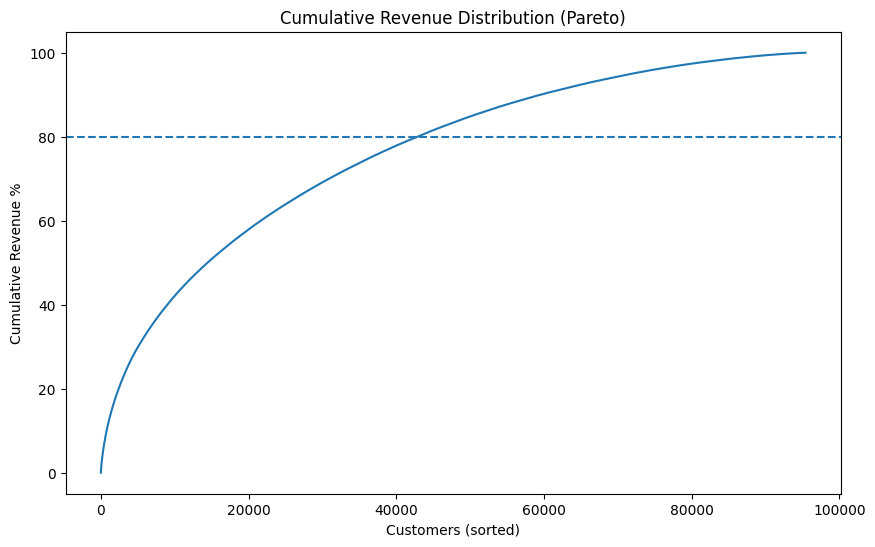

In [41]:
# Visualize cumulative revenue distribution (Pareto Analysis)
plt.figure(figsize=(10,6))

plt.plot(customer_revenue_sorted['cum_revenue_pct'].values)

plt.title('Cumulative Revenue Distribution (Pareto)')
plt.xlabel('Customers (sorted)')
plt.ylabel('Cumulative Revenue %')

plt.axhline(
    y=80,
    linestyle='--'
)

plt.show()

In [42]:
customers_for_80 = (
    customer_revenue_sorted['cum_revenue_pct']
    .le(80)
    .sum()
)

customer_share = (
    customers_for_80 /
    len(customer_revenue_sorted)
) * 100

print(customer_share)

44.88576818277091


Revenue was unevenly distributed across customers, although not highly concentrated. Approximately 45% of customers generated 80% of total revenue, suggesting moderate revenue concentration rather than a classic Pareto (80/20) pattern.

# Conclusions
Business Growth
Revenue and order volume increased substantially throughout 2017 and early 2018.
Revenue growth was primarily driven by increasing order volume rather than higher average order values.
Product Performance
Revenue was concentrated in a limited number of product categories.
Different categories contributed through different business models, combining high-volume and high-value segments.
Customer Behavior
Average Order Value (AOV) was approximately 138 per customer.
Customer spending was unevenly distributed, with a relatively small group of higher-value customers contributing a disproportionate share of total revenue.
Most customers made only a single purchase during the observed period.
Operational Performance
The cancellation rate remained low (~0.63%), suggesting stable operational performance.

## Business Recommendations

### Customer Retention

Most customers placed only a single order during the observed period. The business could evaluate customer retention initiatives, such as loyalty programs or personalized follow-up campaigns, to encourage repeat purchases.

### Product Strategy

Revenue was concentrated in a limited number of product categories. These categories could be prioritized for inventory planning, promotional campaigns, and pricing optimization while maintaining a diversified product portfolio.

### Customer Segmentation

Higher-spending customers contributed a disproportionate share of total revenue. Segmenting and targeting these customers with tailored marketing campaigns or premium offers may help increase customer lifetime value.

## Limitations

- The dataset covers a limited observation period and may not fully reflect long-term customer behavior.
- The first and last months contain partial data and should be interpreted with caution.
- Customer behavior was analyzed only within the available transaction history.

The processed dataset created in this notebook serves as the data source for the accompanying Power BI dashboard.

# Export for Power BI

In [43]:
# Export Final Dataset
category_compare.to_csv('category_analysis.csv', index=False)
customer_revenue.to_csv('customer_analysis.csv', index=False)
monthly_revenue.to_csv('monthly_revenue.csv', index=False)
sales.to_csv('sales_clean.csv', index=False)

# Power BI Dashboard Summary

This dashboard was created to provide business insights into sales performance and customer behavior based on the Olist e-commerce dataset.

The dashboard consists of two analytical views:

1. Sales Performance Dashboard
2. Customer Analysis Dashboard

## Sales Performance Insights

- Revenue and order volume increased significantly throughout the analyzed period.
- Growth in revenue was accompanied by growth in order volume, indicating increasing customer demand.
- A limited number of product categories generated a substantial share of total revenue.
- A partial final month (September 2018) was identified and excluded from trend analysis to avoid misleading conclusions.

## Customer Analysis Insights

- Average Order Value (AOV) was approximately 138.
- Customer spending is highly skewed, with most customers spending relatively small amounts.
- A small number of high-value customers contribute disproportionately to overall revenue.
- Most customers belong to the Low Value segment, while High Value customers represent a small but important customer group.